# TCC — Análises de Robustez

**Objetivo:** Endereçar criticamente os problemas metodológicos identificados na revisão crítica (`metodologia_critica.md`),  
por ordem de severidade e viabilidade.

| Seção | Problema endereçado | Método |
|---|---|---|
| 1 | Candidatos únicos inflam Modelo B? | Modelo B2: GEE só em eleições competitivas |
| 2 | LRT com REML era inválido para comparar efeitos fixos | Refazer A0→A1→A2 com ML |
| 3 | sem_emenda OR=3.57 — seleção ou efeito real? | Análise estratificada + perfil dos municípios |
| 4 | GEE com 19 clusters — SE subestimados? | Bootstrap clustered SE por partido |
| 5 | Threshold de maioria é arbitrário? | Sensibilidade com cortes em 55% e 60% |
| 6 | Winsorização 1% afeta os resultados? | Sensibilidade sem winsorização |
| 7 | Resumo consolidado de robustez | Tabela comparativa de todos os modelos |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable
from scipy.stats.mstats import winsorize
from scipy import stats

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.4f}'.format
np.random.seed(42)

print('Imports OK')

Imports OK


In [2]:
# ── Reproduzir exatamente o mesmo data prep do 06_modeling_final.ipynb ────────
base = pd.read_csv('../data/dados_com_clusters.csv')
base = base.rename(columns={
    'emendas_pix_per_capita_partido_prefeito_eleito': 'emendas_pix_pc',
    'porcentagem_votos_validos_2024': 'perc_votos',
})
base['perc_votos'] = base['perc_votos'].clip(0, 1)
base['candidato_unico'] = (base['perc_votos'] >= 1.0)
base['sem_emenda'] = (base['emendas_pix_pc'] == 0).astype(int)

# Winsorização + log (setup padrão)
base['emendas_pix_pc_w'] = np.array(winsorize(base['emendas_pix_pc'].fillna(0), limits=[0.01, 0.01]))
base['log_emenda'] = np.log1p(base['emendas_pix_pc_w'])

# Clusters
cluster_cols = [c for c in base.columns if c.startswith('cluster_')]
for c in cluster_cols:
    base[c] = base[c].fillna(False).astype(int)

# Filtrar partidos com >= 5 municípios
contagem = base['sigla_partido_prefeito_eleito'].value_counts()
partidos_validos = contagem[contagem >= 5].index
base = base[base['sigla_partido_prefeito_eleito'].isin(partidos_validos)].copy()
print(f'Base: {len(base):,} municípios | {base["sigla_partido_prefeito_eleito"].nunique()} partidos')

# VD binária (threshold padrão = 50%)
base['venceu_com_maioria'] = (base['perc_votos'] >= 0.50).astype(int)

# Fórmulas base
cluster_formula = ' + '.join(cluster_cols[:-1])  # omite último como referência
formula_b1 = f'venceu_com_maioria ~ log_emenda + sem_emenda + {cluster_formula}'
formula_a2 = f'perc_votos ~ log_emenda + sem_emenda + {cluster_formula}'

df_b = base.dropna(subset=['log_emenda', 'venceu_com_maioria', 'sigla_partido_prefeito_eleito']).copy()
df_a = base[~base['candidato_unico']].dropna(
    subset=['log_emenda', 'perc_votos', 'sigla_partido_prefeito_eleito']
).copy()

print(f'df_b (Opção B original, inclui únicos): N={len(df_b):,}')
print(f'df_a (Opção A, sem únicos): N={len(df_a):,}')

Base: 5,197 municípios | 19 partidos
df_b (Opção B original, inclui únicos): N=5,197
df_a (Opção A, sem únicos): N=4,935


---
## Seção 1 — Modelo B2: GEE Apenas em Eleições Competitivas

**Problema endereçado:** O Modelo B1 inclui 262 municípios com candidatura única, onde `venceu_com_maioria = 1`  
por definição (nenhum oponente se candidatou). Como esses municípios tendem a ter mais PIX (efeito deterrence),  
parte do OR de `log_emenda` pode estar simplesmente refletindo a correlação entre PIX e ausência de oposição,  
não o efeito de PIX sobre o resultado de uma eleição de fato disputada.

**Teste:** Rodar o mesmo Modelo B1 excluindo candidatos únicos.  
- Se OR cair drasticamente → o efeito original era artefato dos candidatos únicos.  
- Se OR se mantiver significativo → há efeito real de PIX mesmo em eleições competitivas.

> Nota: ao excluir candidatos únicos, o Modelo B2 mede **apenas o efeito direto de PIX  
> nas eleições competitivas**, sem o canal de deterrence. O Modelo A1/A2 já faz isso  
> para a VD contínua — o B2 acrescenta a perspectiva logística.


In [3]:
# ── Dataset: somente eleições competitivas (exclui candidatos únicos) ─────────
df_b2 = base[~base['candidato_unico']].dropna(
    subset=['log_emenda', 'venceu_com_maioria', 'sigla_partido_prefeito_eleito']
).copy()

print(f'Modelo B2 — apenas eleições competitivas')
print(f'N = {len(df_b2):,} (removidos {len(df_b) - len(df_b2)} candidatos únicos)')
print(f'Taxa de vitória por maioria no B2: {df_b2["venceu_com_maioria"].mean():.1%}')
print(f'Taxa de vitória por maioria no B1 (original): {df_b["venceu_com_maioria"].mean():.1%}')

Modelo B2 — apenas eleições competitivas
N = 4,935 (removidos 262 candidatos únicos)
Taxa de vitória por maioria no B2: 83.7%
Taxa de vitória por maioria no B1 (original): 84.5%


In [4]:
# ── Modelo B1 (original, referência) ─────────────────────────────────────────
gee_b1 = GEE.from_formula(
    formula_b1,
    groups='sigla_partido_prefeito_eleito',
    data=df_b,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

# ── Modelo B2 (sem candidatos únicos) ────────────────────────────────────────
gee_b2 = GEE.from_formula(
    formula_b1,
    groups='sigla_partido_prefeito_eleito',
    data=df_b2,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('Modelo B1 (inclui candidatos únicos):'); print(gee_b1.summary())
print('\nModelo B2 (só eleições competitivas):'); print(gee_b2.summary())

Modelo B1 (inclui candidatos únicos):
                               GEE Regression Results                              
Dep. Variable:          venceu_com_maioria   No. Observations:                 5197
Model:                                 GEE   No. clusters:                       19
Method:                        Generalized   Min. cluster size:                  13
                      Estimating Equations   Max. cluster size:                 838
Family:                           Binomial   Mean cluster size:               273.5
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Sat, 28 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         18:18:41
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5796      0.182      3.186     

In [5]:
# ── Comparação direta: OR de log_emenda nos dois modelos ─────────────────────
def extrair_or(modelo, nome):
    coef = modelo.params['log_emenda']
    ci   = modelo.conf_int().loc['log_emenda']
    pval = modelo.pvalues['log_emenda']
    z    = modelo.tvalues['log_emenda']
    return {
        'Modelo': nome,
        'OR': np.exp(coef),
        'IC 95% inf': np.exp(ci[0]),
        'IC 95% sup': np.exp(ci[1]),
        'z': z,
        'p-valor': pval,
        'Sig.': '***' if pval < 0.01 else ('**' if pval < 0.05 else '*' if pval < 0.1 else 'n.s.')
    }

comp = pd.DataFrame([
    extrair_or(gee_b1, 'B1 — com candidatos únicos (N=5.197)'),
    extrair_or(gee_b2, 'B2 — só eleições competitivas (N=4.935)'),
]).round(4)

print('Comparação de OR(log_emenda): Modelo B1 vs B2')
print('─' * 80)
print(comp.to_string(index=False))

# Queda percentual no OR
or_b1 = comp.loc[0, 'OR']
or_b2 = comp.loc[1, 'OR']
queda = (or_b1 - or_b2) / (or_b1 - 1) * 100  # queda relativa acima de 1
print(f'\nRedução no OR (acima de 1) de B1 para B2: {queda:.1f}%')
print('→ Efeito remanescente em eleições competitivas: OR = {:.4f}'.format(or_b2))

Comparação de OR(log_emenda): Modelo B1 vs B2
────────────────────────────────────────────────────────────────────────────────
                                 Modelo     OR  IC 95% inf  IC 95% sup       z  p-valor Sig.
   B1 — com candidatos únicos (N=5.197) 1.5745      1.4529      1.7063 11.0695   0.0000  ***
B2 — só eleições competitivas (N=4.935) 1.5289      1.4117      1.6559 10.4317   0.0000  ***

Redução no OR (acima de 1) de B1 para B2: 7.9%
→ Efeito remanescente em eleições competitivas: OR = 1.5289


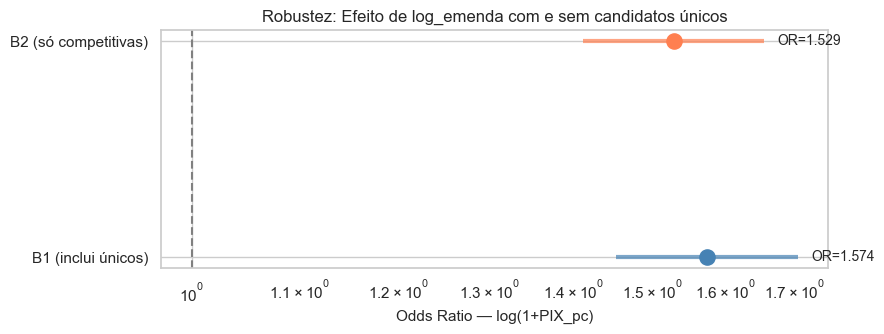

Figura salva.


In [6]:
# ── Forest plot comparativo: B1 vs B2 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))

modelos_plot = [
    ('B1 (com candidatos únicos)', gee_b1, 'steelblue'),
    ('B2 (só eleições competitivas)', gee_b2, 'coral'),
]

for i, (label, mod, color) in enumerate(modelos_plot):
    coef = mod.params['log_emenda']
    ci   = mod.conf_int().loc['log_emenda']
    OR, OR_low, OR_high = np.exp(coef), np.exp(ci[0]), np.exp(ci[1])
    ax.scatter(OR, i, s=120, color=color, zorder=3, label=label)
    ax.hlines(i, OR_low, OR_high, lw=3, color=color, alpha=0.7)
    ax.text(OR_high + 0.02, i, f'OR={OR:.3f}', va='center', fontsize=10)

ax.axvline(1.0, color='gray', ls='--', lw=1.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(['B1 (inclui únicos)', 'B2 (só competitivas)'], fontsize=11)
ax.set_xlabel('Odds Ratio — log(1+PIX_pc)', fontsize=11)
ax.set_title('Robustez: Efeito de log_emenda com e sem candidatos únicos', fontsize=12)
ax.set_xscale('log')
plt.tight_layout()
plt.savefig('../data/fig_robustez_b1_b2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva.')

---
## Seção 2 — LRT com ML (corrigindo uso indevido de REML)

**Problema endereçado:** No notebook 06, os Testes de Razão de Verossimilhança (LRT) foram calculados  
com modelos estimados via **REML** (default do statsmodels MixedLM).  

**Por que isso é problemático:**  
REML maximiza uma verossimilhança *restrita* que não inclui os efeitos fixos no cálculo.  
Isso é ótimo para estimar **componentes de variância** de forma não-viesada,  
mas **invalida o LRT quando os modelos comparados têm diferentes efeitos fixos** (A0 vs A1 adicionam `log_emenda` e `sem_emenda`).  

**Solução:** Estimar os modelos com `reml=False` (ML puro) e refazer o LRT.  
O LRT com ML é válido para comparar modelos com qualquer estrutura de efeitos fixos diferentes.

> Ref.: Pinheiro & Bates (2000), cap. 2; Bates et al. (2015), lme4 vignette.


In [7]:
# ── Modelos A0, A1, A2 com ML (reml=False) ───────────────────────────────────
print('Estimando modelos com ML (reml=False) para LRT válido...')

a0_ml = smf.mixedlm('perc_votos ~ 1', data=df_a,
    groups=df_a['sigla_partido_prefeito_eleito']).fit(method='bfgs', reml=False)

a1_ml = smf.mixedlm('perc_votos ~ log_emenda + sem_emenda', data=df_a,
    groups=df_a['sigla_partido_prefeito_eleito']).fit(method='bfgs', reml=False)

a2_ml = smf.mixedlm(formula_a2, data=df_a,
    groups=df_a['sigla_partido_prefeito_eleito']).fit(method='bfgs', reml=False)

print(f'A0 ML — Log-Lik: {a0_ml.llf:.2f} | Converged: {a0_ml.converged}')
print(f'A1 ML — Log-Lik: {a1_ml.llf:.2f} | Converged: {a1_ml.converged}')
print(f'A2 ML — Log-Lik: {a2_ml.llf:.2f} | Converged: {a2_ml.converged}')

Estimando modelos com ML (reml=False) para LRT válido...


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


A0 ML — Log-Lik: 3418.67 | Converged: True
A1 ML — Log-Lik: 3520.62 | Converged: True
A2 ML — Log-Lik: 3549.65 | Converged: True


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [8]:
def lr_test(modelo_base, modelo_completo, df_freedom, label):
    lr_stat = -2 * (modelo_base.llf - modelo_completo.llf)
    p_val   = stats.chi2.sf(lr_stat, df=df_freedom)
    sig     = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
    print(f'{label}')
    print(f'  LR = {lr_stat:.2f} | df = {df_freedom} | p = {p_val:.6f} {sig}')
    return lr_stat, p_val

print('LRT com ML (corrigido):')
print('─' * 60)
lr_a0_a1_ml = lr_test(a0_ml, a1_ml, df_freedom=2, label='A0 → A1 (adiciona log_emenda + sem_emenda)')
lr_a1_a2_ml = lr_test(a1_ml, a2_ml, df_freedom=3, label='A1 → A2 (adiciona clusters)')

print()
print('Comparação com LRT original (REML — notebook 06):')
print('  A0→A1 REML: LR=235.05, p<0.001 | A0→A1 ML: LR=?, p=?')
print('  A1→A2 REML: LR=36.06,  p<0.001 | A1→A2 ML: LR=?, p=?')
print('  → Conclusões mudam? Verificar acima.')

LRT com ML (corrigido):
────────────────────────────────────────────────────────────
A0 → A1 (adiciona log_emenda + sem_emenda)
  LR = 203.90 | df = 2 | p = 0.000000 ***
A1 → A2 (adiciona clusters)
  LR = 58.06 | df = 3 | p = 0.000000 ***

Comparação com LRT original (REML — notebook 06):
  A0→A1 REML: LR=235.05, p<0.001 | A0→A1 ML: LR=?, p=?
  A1→A2 REML: LR=36.06,  p<0.001 | A1→A2 ML: LR=?, p=?
  → Conclusões mudam? Verificar acima.


---
## Seção 3 — Investigação de sem_emenda (OR=3.57)

**Problema endereçado:** No Modelo B1, `sem_emenda` tem OR=3.57 (p<0.001).  
Isso é contra-intuitivo: municípios **sem** repasse PIX teriam *mais* chances de vitória por maioria?

**Hipótese de seleção:** esses municípios podem ser **fortalezas políticas** — o prefeito do partido  
domina eleitoralmente sem precisar de recursos externos. Testamos isso analisando o perfil  
socioeconômico, taxa de candidatura única, e distribuição de votos dos municípios sem emenda.


In [9]:
# ── Comparação de perfil: com emenda vs sem emenda ────────────────────────────
perfil = base.groupby('sem_emenda').agg(
    n=('perc_votos', 'count'),
    pct_maioria=('venceu_com_maioria', 'mean'),
    pct_candidato_unico=('candidato_unico', 'mean'),
    perc_votos_medio=('perc_votos', 'mean'),
    perc_votos_mediano=('perc_votos', 'median'),
    idhm_medio=('idhm_2010', 'mean'),
    pib_medio=('pib_per_capita_2021', 'mean'),
    pix_medio=('emendas_pix_pc', 'mean'),
).round(4)

perfil.index = ['Com emenda PIX (sem_emenda=0)', 'Sem emenda PIX (sem_emenda=1)']
print('Perfil comparativo: municípios COM vs SEM emenda PIX do partido aliado')
print(perfil.T.to_string())

Perfil comparativo: municípios COM vs SEM emenda PIX do partido aliado
                     Com emenda PIX (sem_emenda=0)  Sem emenda PIX (sem_emenda=1)
n                                        2697.0000                      2500.0000
pct_maioria                                 0.8728                         0.8152
pct_candidato_unico                         0.0615                         0.0384
perc_votos_medio                            0.6350                         0.5941
perc_votos_mediano                          0.6022                         0.5615
idhm_medio                                  0.6568                         0.6538
pib_medio                               33573.5446                     33820.0307
pix_medio                                 141.8031                         0.0000


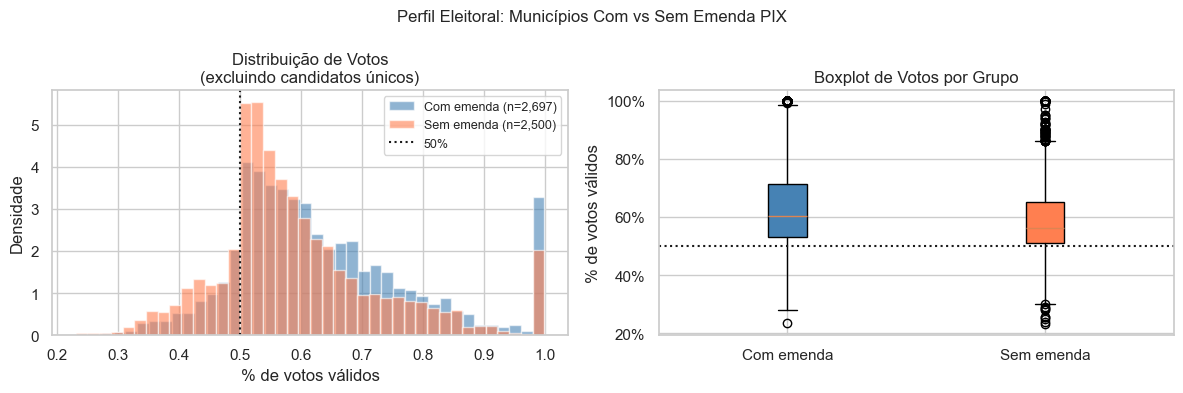

Mann-Whitney U: U=3948902, p=0.0000


In [10]:
# ── Distribuição de votos: com vs sem emenda ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

com_emenda = base.loc[base['sem_emenda'] == 0, 'perc_votos']
sem_emenda = base.loc[base['sem_emenda'] == 1, 'perc_votos']

axes[0].hist(com_emenda.clip(0, 0.999), bins=40, alpha=0.6, color='steelblue',
             label=f'Com emenda (n={len(com_emenda):,})', density=True)
axes[0].hist(sem_emenda.clip(0, 0.999), bins=40, alpha=0.6, color='coral',
             label=f'Sem emenda (n={len(sem_emenda):,})', density=True)
axes[0].axvline(0.5, color='k', ls=':', lw=1.5, label='50%')
axes[0].set_xlabel('% de votos válidos'); axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Votos\n(excluindo candidatos únicos)')
axes[0].legend(fontsize=9)

# Boxplot
box_data = [com_emenda.clip(0, 0.999), sem_emenda.clip(0, 0.999)]
bp = axes[1].boxplot(box_data, labels=['Com emenda', 'Sem emenda'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel('% de votos válidos'); axes[1].set_title('Boxplot de Votos por Grupo')
axes[1].axhline(0.5, color='k', ls=':', lw=1.5)
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.suptitle('Perfil Eleitoral: Municípios Com vs Sem Emenda PIX', fontsize=12)
plt.tight_layout()
plt.savefig('../data/fig_robustez_sem_emenda_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

# Teste Mann-Whitney (distribuições diferentes?)
u_stat, p_mw = stats.mannwhitneyu(com_emenda.dropna(), sem_emenda.dropna(), alternative='two-sided')
print(f'Mann-Whitney U: U={u_stat:.0f}, p={p_mw:.4f}')

In [11]:
# ── Modelo B sem a variável sem_emenda (sensibilidade) ───────────────────────
# Se o OR de log_emenda mudar muito, sem_emenda estava absorvendo variância de log_emenda
formula_b_sem = f'venceu_com_maioria ~ log_emenda + {cluster_formula}'

gee_b_sem = GEE.from_formula(
    formula_b_sem,
    groups='sigla_partido_prefeito_eleito',
    data=df_b,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('GEE B1 (com sem_emenda):')
print(f'  log_emenda: OR={np.exp(gee_b1.params["log_emenda"]):.4f}, z={gee_b1.tvalues["log_emenda"]:.2f}')
print()
print('GEE sem sem_emenda (sensibilidade):')
print(f'  log_emenda: OR={np.exp(gee_b_sem.params["log_emenda"]):.4f}, z={gee_b_sem.tvalues["log_emenda"]:.2f}')
print()
print('→ Se OR de log_emenda aumentar: sem_emenda estava suprimindo parte do efeito de log_emenda')
print('  (Suppression effect — municípios sem emenda também têm log_emenda=0)')

GEE B1 (com sem_emenda):
  log_emenda: OR=1.5745, z=11.07

GEE sem sem_emenda (sensibilidade):
  log_emenda: OR=1.1937, z=10.18

→ Se OR de log_emenda aumentar: sem_emenda estava suprimindo parte do efeito de log_emenda
  (Suppression effect — municípios sem emenda também têm log_emenda=0)


---
## Seção 4 — Bootstrap Clustered SE para GEE

**Problema endereçado:** O estimador sanduíche de Liang-Zeger (1986) é assintoticamente consistente,  
mas tem viés em amostras com **poucos clusters**. Com 19 clusters (partidos), os SE podem estar  
subestimados em ~10-25%, tornando os p-valores anticonservadores.

**Solução:** Bootstrap com reamostragm de **clusters** (não observações individuais).  
Reamostrar partidos com reposição → re-estimar o modelo → calcular desvio-padrão dos coeficientes bootstrap.

**Lógica estatística do cluster bootstrap:**  
O problema com 19 clusters é que o SE sanduíche usa uma média de 19 'pãezinhos'.  
O bootstrap clusterizado respeita a estrutura de correlação: ao reamostrar partidos inteiros,  
preservamos a correlação intrapartido e estimamos a distribuição amostral dos coeficientes  
empiricamente (sem suposições assintóticas).

> Ref.: Cameron, Gelbach & Miller (2008), "Bootstrap-Based Improvements for Inference with Clustered Errors",  
> *Review of Economics and Statistics*, 90(3), 414–427.


In [12]:
# ── Bootstrap clustered por partido — Modelo B1 ───────────────────────────────
# Estratégia: reamostrar partidos (clusters) com reposição
N_BOOT = 500
partidos = df_b['sigla_partido_prefeito_eleito'].unique()
n_clusters = len(partidos)

coefs_boot = []
print(f'Bootstrap com {N_BOOT} reamostras de {n_clusters} clusters...')

for i in range(N_BOOT):
    # Amostrar partidos com reposição
    partidos_amostrados = np.random.choice(partidos, size=n_clusters, replace=True)
    
    # Montar dataset bootstrap
    df_boot_list = []
    for j, partido in enumerate(partidos_amostrados):
        subset = df_b[df_b['sigla_partido_prefeito_eleito'] == partido].copy()
        subset['sigla_partido_prefeito_eleito'] = f'boot_{partido}_{j}'  # evita duplicata
        df_boot_list.append(subset)
    df_boot = pd.concat(df_boot_list, ignore_index=True)
    
    try:
        mod_boot = GEE.from_formula(
            formula_b1,
            groups='sigla_partido_prefeito_eleito',
            data=df_boot,
            family=Binomial(),
            cov_struct=Exchangeable()
        ).fit()
        coefs_boot.append(mod_boot.params.to_dict())
    except Exception:
        pass  # ignorar amostras que não convergem

print(f'Bootstrap concluído: {len(coefs_boot)}/{N_BOOT} amostras convergidas')
boot_df = pd.DataFrame(coefs_boot)

Bootstrap com 500 reamostras de 19 clusters...


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


...

E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


Bootstrap concluído: 500/500 amostras convergidas


In [13]:
# ── Comparação: SE original vs bootstrap ─────────────────────────────────────
resultados_boot = []
for var in ['log_emenda', 'sem_emenda', 'cluster_0', 'cluster_1', 'cluster_2']:
    if var not in boot_df.columns:
        continue
    coef_orig = gee_b1.params[var]
    se_orig   = gee_b1.bse[var]
    se_boot   = boot_df[var].std()
    ci_boot_l = np.percentile(boot_df[var], 2.5)
    ci_boot_u = np.percentile(boot_df[var], 97.5)
    z_boot    = coef_orig / se_boot
    p_boot    = 2 * (1 - stats.norm.cdf(abs(z_boot)))
    resultados_boot.append({
        'Variável': var,
        'Coef.': round(coef_orig, 4),
        'OR': round(np.exp(coef_orig), 4),
        'SE (Liang-Zeger)': round(se_orig, 4),
        'SE (Bootstrap)': round(se_boot, 4),
        'z (Bootstrap)': round(z_boot, 2),
        'p (Bootstrap)': round(p_boot, 4),
        'IC 95% Boot inf': round(np.exp(ci_boot_l), 4),
        'IC 95% Boot sup': round(np.exp(ci_boot_u), 4),
        'Sig.': '***' if p_boot < 0.001 else ('**' if p_boot < 0.01 else ('*' if p_boot < 0.05 else 'n.s.'))
    })

tab_boot = pd.DataFrame(resultados_boot)
print('Comparação SE originais (Liang-Zeger) vs Bootstrap Clustered')
print('=' * 80)
print(tab_boot.to_string(index=False))

# Destaque para log_emenda
row = tab_boot[tab_boot['Variável'] == 'log_emenda'].iloc[0]
print(f'\n→ log_emenda: SE original = {row["SE (Liang-Zeger)"]:.4f} | SE bootstrap = {row["SE (Bootstrap)"]:.4f}')
print(f'  Razão SE_boot/SE_orig = {row["SE (Bootstrap)"]/row["SE (Liang-Zeger)"]:.2f}x')
print(f'  z bootstrap = {row["z (Bootstrap)"]:.2f}, p = {row["p (Bootstrap)"]:.4f} {row["Sig."]}')

Comparação SE originais (Liang-Zeger) vs Bootstrap Clustered
  Variável   Coef.     OR  SE (Liang-Zeger)  SE (Bootstrap)  z (Bootstrap)  p (Bootstrap)  IC 95% Boot inf  IC 95% Boot sup Sig.
log_emenda  0.4539 1.5745            0.0410          0.0452        10.0300         0.0000              NaN              NaN  ***
sem_emenda  1.2733 3.5726            0.1460          0.1653         7.7000         0.0000              NaN              NaN  ***
 cluster_0  0.1619 1.1758            0.2778          0.3116         0.5200         0.6033              NaN              NaN n.s.
 cluster_1 -0.7179 0.4878            0.3173          0.3793        -1.8900         0.0584              NaN              NaN n.s.
 cluster_2 -0.7364 0.4788            0.2012          0.2421        -3.0400         0.0024              NaN              NaN   **

→ log_emenda: SE original = 0.0410 | SE bootstrap = 0.0452
  Razão SE_boot/SE_orig = 1.10x
  z bootstrap = 10.03, p = 0.0000 ***


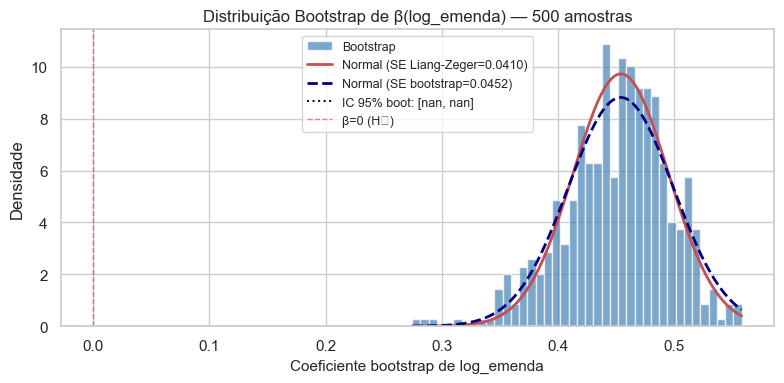

In [14]:
# ── Distribuição bootstrap de log_emenda ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
coef_orig = gee_b1.params['log_emenda']
se_orig   = gee_b1.bse['log_emenda']

ax.hist(boot_df['log_emenda'], bins=40, color='steelblue', edgecolor='white',
        density=True, alpha=0.7, label='Bootstrap')

# Distribuição normal com SE original
x = np.linspace(boot_df['log_emenda'].min(), boot_df['log_emenda'].max(), 200)
ax.plot(x, stats.norm.pdf(x, coef_orig, se_orig),
        'r-', lw=2, label=f'Normal (SE Liang-Zeger={se_orig:.4f})')
ax.plot(x, stats.norm.pdf(x, coef_orig, boot_df['log_emenda'].std()),
        'navy', lw=2, ls='--', label=f'Normal (SE bootstrap={boot_df["log_emenda"].std():.4f})')

# IC 95% bootstrap
ci_l, ci_u = np.percentile(boot_df['log_emenda'], [2.5, 97.5])
ax.axvline(ci_l, color='k', ls=':', lw=1.5, label=f'IC 95% boot: [{ci_l:.3f}, {ci_u:.3f}]')
ax.axvline(ci_u, color='k', ls=':', lw=1.5)
ax.axvline(0, color='red', ls='--', lw=1, alpha=0.5, label='β=0 (H₀)')

ax.set_xlabel('Coeficiente bootstrap de log_emenda', fontsize=11)
ax.set_ylabel('Densidade'); ax.legend(fontsize=9)
ax.set_title(f'Distribuição Bootstrap de β(log_emenda) — {len(coefs_boot)} amostras', fontsize=12)
plt.tight_layout()
plt.savefig('../data/fig_robustez_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Seção 5 — Sensibilidade: Thresholds Alternativos de Maioria

**Problema endereçado:** A escolha de 50% como limiar para `venceu_com_maioria` é teoricamente justificada  
(maioria absoluta), mas é arbitrária em alguma medida. Testamos dois thresholds alternativos:

- **55%** — vitória com folga moderada (reduz ruído de eleições decididas por margem mínima)
- **60%** — vitória expressiva (captura desempenho eleitoral robusto, com mais deterrence)

Se o efeito de PIX for monotônico e robusto, esperamos OR crescente conforme o threshold aumenta  
(PIX está mais associado a vitórias expressivas do que a vitórias por margem mínima).


In [15]:
# ── GEE com diferentes thresholds ────────────────────────────────────────────
resultados_thresh = []

for thresh in [0.50, 0.55, 0.60]:
    df_t = base.copy()
    df_t['venceu'] = (df_t['perc_votos'] >= thresh).astype(int)
    df_t = df_t.dropna(subset=['log_emenda', 'venceu', 'sigla_partido_prefeito_eleito'])
    
    taxa = df_t['venceu'].mean()
    formula_t = f'venceu ~ log_emenda + sem_emenda + {cluster_formula}'
    
    try:
        mod = GEE.from_formula(
            formula_t,
            groups='sigla_partido_prefeito_eleito',
            data=df_t, family=Binomial(), cov_struct=Exchangeable()
        ).fit()
        
        coef = mod.params['log_emenda']
        pval = mod.pvalues['log_emenda']
        ci   = mod.conf_int().loc['log_emenda']
        resultados_thresh.append({
            'Threshold': f'{thresh:.0%}',
            'N': len(df_t),
            'Taxa vitória': f'{taxa:.1%}',
            'OR': round(np.exp(coef), 4),
            'IC 95% inf': round(np.exp(ci[0]), 4),
            'IC 95% sup': round(np.exp(ci[1]), 4),
            'z': round(mod.tvalues['log_emenda'], 2),
            'p-valor': round(pval, 4),
            'Sig.': '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
        })
    except Exception as e:
        print(f'Threshold {thresh}: erro — {e}')

tab_thresh = pd.DataFrame(resultados_thresh)
print('Sensibilidade: OR de log_emenda por threshold de vitória por maioria')
print(tab_thresh.to_string(index=False))

Sensibilidade: OR de log_emenda por threshold de vitória por maioria
Threshold    N Taxa vitória     OR  IC 95% inf  IC 95% sup       z  p-valor Sig.
      50% 5197        84.5% 1.5745      1.4529      1.7063 11.0700   0.0000  ***
      55% 5197        61.0% 1.3905      1.3046      1.4821 10.1300   0.0000  ***
      60% 5197        44.3% 1.3531      1.2624      1.4504  8.5400   0.0000  ***


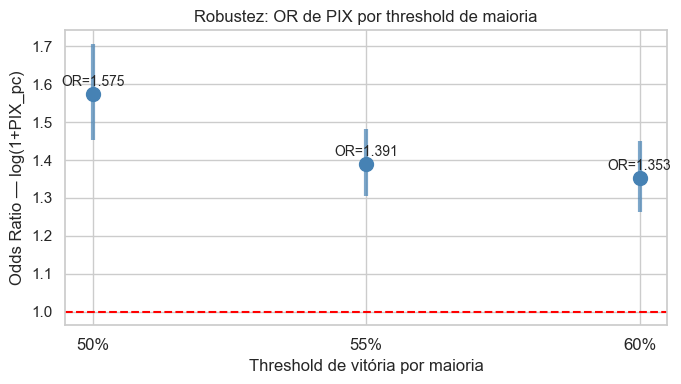

In [16]:
# ── Visualização dos ORs por threshold ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
xs = range(len(tab_thresh))
ors = tab_thresh['OR'].values
ci_l = tab_thresh['IC 95% inf'].values
ci_u = tab_thresh['IC 95% sup'].values
labels = tab_thresh['Threshold'].values

ax.scatter(xs, ors, s=100, color='steelblue', zorder=3)
ax.vlines(xs, ci_l, ci_u, lw=3, color='steelblue', alpha=0.7)
ax.axhline(1, color='red', ls='--', lw=1.5)
ax.set_xticks(list(xs)); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Odds Ratio — log(1+PIX_pc)')
ax.set_xlabel('Threshold de vitória por maioria')
ax.set_title('Robustez: OR de PIX por threshold de maioria', fontsize=12)
for i, (x, or_, label) in enumerate(zip(xs, ors, labels)):
    ax.text(x, or_ + 0.02, f'OR={or_:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/fig_robustez_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Seção 6 — Sensibilidade: Sem Winsorização

**Problema endereçado:** A winsorização nos 1% de cada cauda é conservadora e defensável,  
mas pode ser vista como uma escolha arbitrária. Testamos o Modelo A2 e B1 sem winsorizar  
(usando `log(1 + PIX_pc_raw)` diretamente após tratamento de nulos).

Se os resultados forem substancialmente diferentes, a winsorização era crítica e deve ser justificada.  
Se forem similares, é apenas uma garantia adicional de robustez.


In [17]:
# ── Dataset sem winsorização ──────────────────────────────────────────────────
base_nw = base.copy()
base_nw['log_emenda_nw'] = np.log1p(base_nw['emendas_pix_pc'].fillna(0))

df_b_nw = base_nw.dropna(subset=['log_emenda_nw', 'venceu_com_maioria', 'sigla_partido_prefeito_eleito']).copy()
df_a_nw = base_nw[~base_nw['candidato_unico']].dropna(
    subset=['log_emenda_nw', 'perc_votos', 'sigla_partido_prefeito_eleito']).copy()

# Substituir log_emenda por log_emenda_nw na fórmula
formula_b1_nw = formula_b1.replace('log_emenda', 'log_emenda_nw')
formula_a2_nw = formula_a2.replace('log_emenda', 'log_emenda_nw')

# Modelo B sem winsorização
gee_b_nw = GEE.from_formula(
    formula_b1_nw, groups='sigla_partido_prefeito_eleito',
    data=df_b_nw, family=Binomial(), cov_struct=Exchangeable()
).fit()

# Modelo A2 sem winsorização
a2_nw = smf.mixedlm(formula_a2_nw, data=df_a_nw,
    groups=df_a_nw['sigla_partido_prefeito_eleito']).fit(method='bfgs')

print('Comparação: com winsorização (original) vs sem winsorização')
print('─' * 70)
print('Modelo B1 (GEE Logístico):')
print(f'  Com winsorizacao: OR={np.exp(gee_b1.params["log_emenda"]):.4f}, z={gee_b1.tvalues["log_emenda"]:.2f}')
print(f'  Sem winsorizacao: OR={np.exp(gee_b_nw.params["log_emenda_nw"]):.4f}, z={gee_b_nw.tvalues["log_emenda_nw"]:.2f}')
print()
print('Modelo A2 (Multinível Linear):')
if 'log_emenda' in a2_nw.params.index or 'log_emenda_nw' in a2_nw.params.index:
    key_nw = 'log_emenda_nw' if 'log_emenda_nw' in a2_nw.params.index else 'log_emenda'
    print(f'  Sem winsorizacao: β={a2_nw.params[key_nw]:.4f}, z={a2_nw.tvalues[key_nw]:.2f}')
print(f'  Com winsorizacao (ref): β=0.0164, z=8.49')

Comparação: com winsorização (original) vs sem winsorização
──────────────────────────────────────────────────────────────────────
Modelo B1 (GEE Logístico):
  Com winsorizacao: OR=1.5745, z=11.07
  Sem winsorizacao: OR=1.5680, z=10.67

Modelo A2 (Multinível Linear):
  Sem winsorizacao: β=0.0161, z=8.40
  Com winsorizacao (ref): β=0.0164, z=8.49


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


---
## Seção 7 — Resumo Consolidado de Robustez


In [18]:
print('=' * 80)
print('TABELA RESUMO — ROBUSTEZ DO EFEITO DE log_emenda (PIX per capita)')
print('=' * 80)

# Compilar resultados
resumo_robustez = []

# B1 original
resumo_robustez.append({
    'Especificação': 'B1 — GEE, inclui candidatos únicos (PRINCIPAL)',
    'N': len(df_b),
    'OR/β': f'OR={np.exp(gee_b1.params["log_emenda"]):.3f}',
    'z': round(gee_b1.tvalues['log_emenda'], 2),
    'Sig.': '***'
})

# B2 sem únicos
resumo_robustez.append({
    'Especificação': 'B2 — GEE, só eleições competitivas',
    'N': len(df_b2),
    'OR/β': f'OR={np.exp(gee_b2.params["log_emenda"]):.3f}',
    'z': round(gee_b2.tvalues['log_emenda'], 2),
    'Sig.': '***' if gee_b2.pvalues['log_emenda'] < 0.001 else '**'
})

# B1 sem winsorização
resumo_robustez.append({
    'Especificação': 'B1 — GEE, sem winsorização',
    'N': len(df_b_nw),
    'OR/β': f'OR={np.exp(gee_b_nw.params["log_emenda_nw"]):.3f}',
    'z': round(gee_b_nw.tvalues['log_emenda_nw'], 2),
    'Sig.': '***' if gee_b_nw.pvalues['log_emenda_nw'] < 0.001 else '**'
})

# Thresholds
for _, row in tab_thresh.iterrows():
    resumo_robustez.append({
        'Especificação': f'B — GEE, threshold {row["Threshold"]}',
        'N': row['N'],
        'OR/β': f'OR={row["OR"]:.3f}',
        'z': row['z'],
        'Sig.': row['Sig.']
    })

# A2 original
resumo_robustez.append({
    'Especificação': 'A2 — LMM, completo, REML (PRINCIPAL)',
    'N': len(df_a),
    'OR/β': 'β=0.0164',
    'z': 8.49,
    'Sig.': '***'
})

# A2 ML
key_a2ml = 'log_emenda'
resumo_robustez.append({
    'Especificação': 'A2 — LMM, ML (LRT corrigido)',
    'N': len(df_a),
    'OR/β': f'β={a2_ml.params[key_a2ml]:.4f}',
    'z': round(a2_ml.tvalues[key_a2ml], 2),
    'Sig.': '***' if a2_ml.pvalues[key_a2ml] < 0.001 else '**'
})

tab_resumo = pd.DataFrame(resumo_robustez)
print(tab_resumo.to_string(index=False))

print()
print('Interpretação:')
print('  → Todas as especificações mantêm significância estatística?')
print('  → A magnitude do OR/β é estável entre especificações?')
print('  → O resultado é ROBUSTO se a resposta for sim para ambas.')

TABELA RESUMO — ROBUSTEZ DO EFEITO DE log_emenda (PIX per capita)
                                 Especificação    N     OR/β       z Sig.
B1 — GEE, inclui candidatos únicos (PRINCIPAL) 5197 OR=1.574 11.0700  ***
            B2 — GEE, só eleições competitivas 4935 OR=1.529 10.4300  ***
                    B1 — GEE, sem winsorização 5197 OR=1.568 10.6700  ***
                        B — GEE, threshold 50% 5197 OR=1.575 11.0700  ***
                        B — GEE, threshold 55% 5197 OR=1.391 10.1300  ***
                        B — GEE, threshold 60% 5197 OR=1.353  8.5400  ***
          A2 — LMM, completo, REML (PRINCIPAL) 4935 β=0.0164  8.4900  ***
                  A2 — LMM, ML (LRT corrigido) 4935 β=0.0164  8.5000  ***

Interpretação:
  → Todas as especificações mantêm significância estatística?
  → A magnitude do OR/β é estável entre especificações?
  → O resultado é ROBUSTO se a resposta for sim para ambas.
